# CAVS: Advanced Coasting

This Connected Automated Vehicle (CAV) demo configures coasting with
additional parameters: brake start speed, passing behavior, maximum coast
speed, and a look-ahead time horizon.

In [1]:
import os

import seaborn as sns

import sys
from pathlib import Path

import fastsim as fsim
from plot_utils import plot_speed_by_time, plot_speed_by_dist

In [2]:
sns.set_theme()

SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

## Setup

In [3]:
veh = fsim.Vehicle.from_resource("2012_Ford_Fusion.yaml")
veh.set_save_interval(1)

cyc = fsim.Cycle.from_resource("udds.csv")
end_idle_duration_s = cyc.ending_idle_time_s()
cyc0 = cyc.copy()
cyc = cyc.extend_time(absolute_time_s=120.0, time_fraction=0.25)

## Configure Coasting Parameters

These parameters control when and how the vehicle coasts:
- `coast_brake_start_speed`: speed at which mechanical braking initiates during coast
- `coast_allow_passing`: whether the coasting vehicle can pass the reference trace
- `coast_max_speed`: maximum allowable speed during coast
- `coast_time_horizon_for_adjustment`: look-ahead time for considering coast opportunities

In [4]:
man = fsim.Maneuver.create_from(cyc, veh.copy())
d = man.to_pydict()
d["coast_allow"] = True
d["coast_brake_start_speed_meters_per_second"] = 8.9408  # 20 mph
d["coast_brake_accel_meters_per_second_squared"] = -2.5
d["favor_grade_accuracy"] = True
d["coast_allow_passing"] = True
d["coast_max_speed_meters_per_second"] = 33.5280  # 75 mph
d["coast_time_horizon_for_adjustment_seconds"] = 120.0
man = fsim.Maneuver.from_pydict(d)

cyc = man.apply_maneuvers()
cyc = cyc.trim_ending_idle(idle_to_keep_s=end_idle_duration_s)

In [5]:
sd = fsim.SimDrive(veh, cyc)
sd.walk()

## Results

Original cycle speed vs. achieved speed with advanced coasting applied.

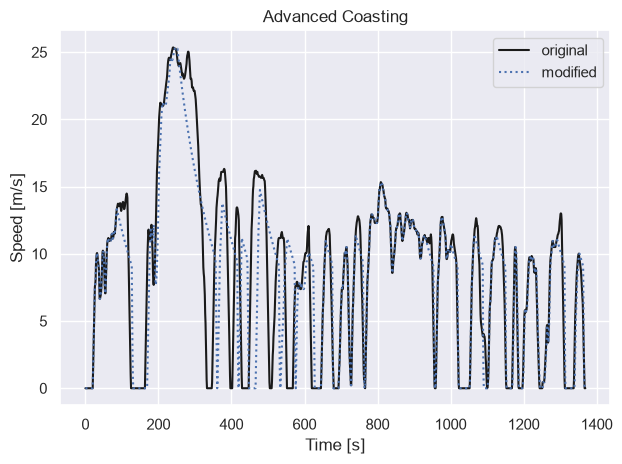

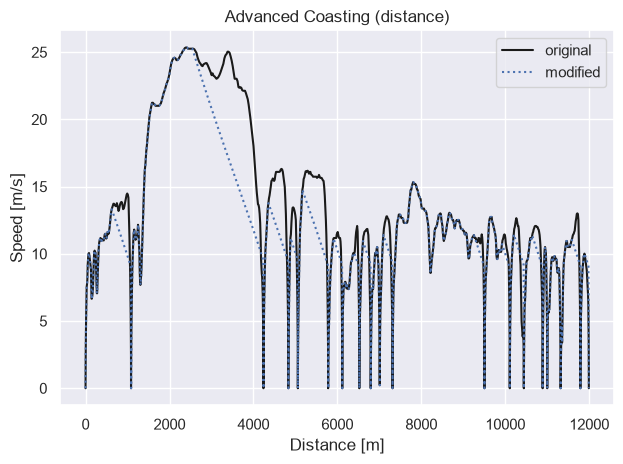

In [6]:
if SHOW_PLOTS:
    c0 = cyc0.to_pydict()
    df = sd.to_dataframe()
    plot_speed_by_time(df, c0, title="Advanced Coasting",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)
    plot_speed_by_dist(df, c0, title="Advanced Coasting (distance)",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)